In [ ]:
# TODO: add the investigation part on aspect ratios and incorrect samples

In [1]:
import torch
from torch.utils.data import DataLoader
from torchvision import transforms
import matplotlib.pyplot as plt
import numpy as np
from iam_dataset import IAMWordDataset
from transforms import StandardizeAspectRatio



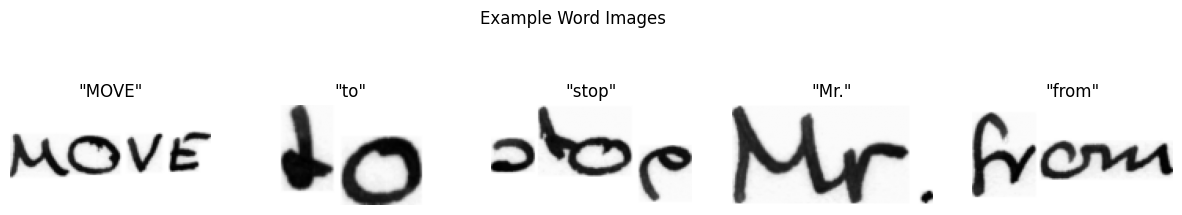

In [12]:

# Create dataset without resizing to see original dimensions
transform = transforms.Compose([
    StandardizeAspectRatio(2),
    transforms.ToPILImage(),
    transforms.Resize((64, 128)),
    transforms.ToTensor(),
])

dataset = IAMWordDataset(
    root_dir='/mnt/speech6/bagher/nafshar//datasets/IAM',
    split='train',
    transform=transform,
    max_word_length=5,
    min_word_length=2
)

# Part 1: Show example images with their text
plt.figure(figsize=(15, 3))
for i in range(5):
    img, text = dataset[i]
    decoded_text = dataset.decode_text(text)
    
    plt.subplot(1, 5, i+1)
    plt.imshow(img.squeeze().numpy(), cmap='gray')
    plt.title(f'"{decoded_text}"')
    plt.axis('off')
plt.suptitle('Example Word Images')
plt.show()


In [13]:
len(dataset)

67436

Error at index 66395: cannot identify image file '/mnt/speech6/bagher/nafshar//datasets/IAM/words/r06/r06-022/r06-022-03-05.png'


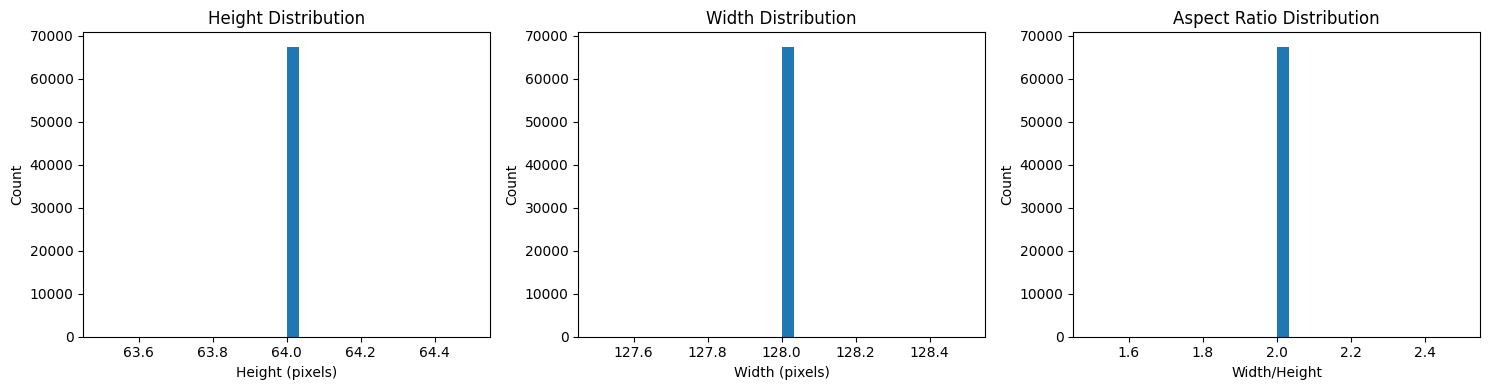

In [14]:

# Part 2: Analyze and visualize image dimensions
heights = []
widths = []
aspect_ratios = []

for i in range(len(dataset)):
    try:
        img, _ = dataset[i]
    except Exception as e:
        print(f"Error at index {i}: {e}")
        continue
    h, w = img.shape[1:]  # Height and width
    heights.append(h)
    widths.append(w)
    aspect_ratios.append(w/h)

# Create subplots for dimension analysis
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Height distribution
axes[0].hist(heights, bins=30)
axes[0].set_title('Height Distribution')
axes[0].set_xlabel('Height (pixels)')
axes[0].set_ylabel('Count')

# Width distribution
axes[1].hist(widths, bins=30)
axes[1].set_title('Width Distribution')
axes[1].set_xlabel('Width (pixels)')
axes[1].set_ylabel('Count')

# Aspect ratio distribution
axes[2].hist(aspect_ratios, bins=30)
axes[2].set_title('Aspect Ratio Distribution')
axes[2].set_xlabel('Width/Height')
axes[2].set_ylabel('Count')

plt.tight_layout()
plt.show()



Image Dimension Statistics:
Height - Mean: 71.7, Min: 1, Max: 277
Width  - Mean: 129.8, Min: 1, Max: 1934
Aspect Ratio - Mean: 1.98, Min: 0.14, Max: 32.14
Error at index 779: Invalid shape () for image data
Error at index 779: Invalid shape () for image data


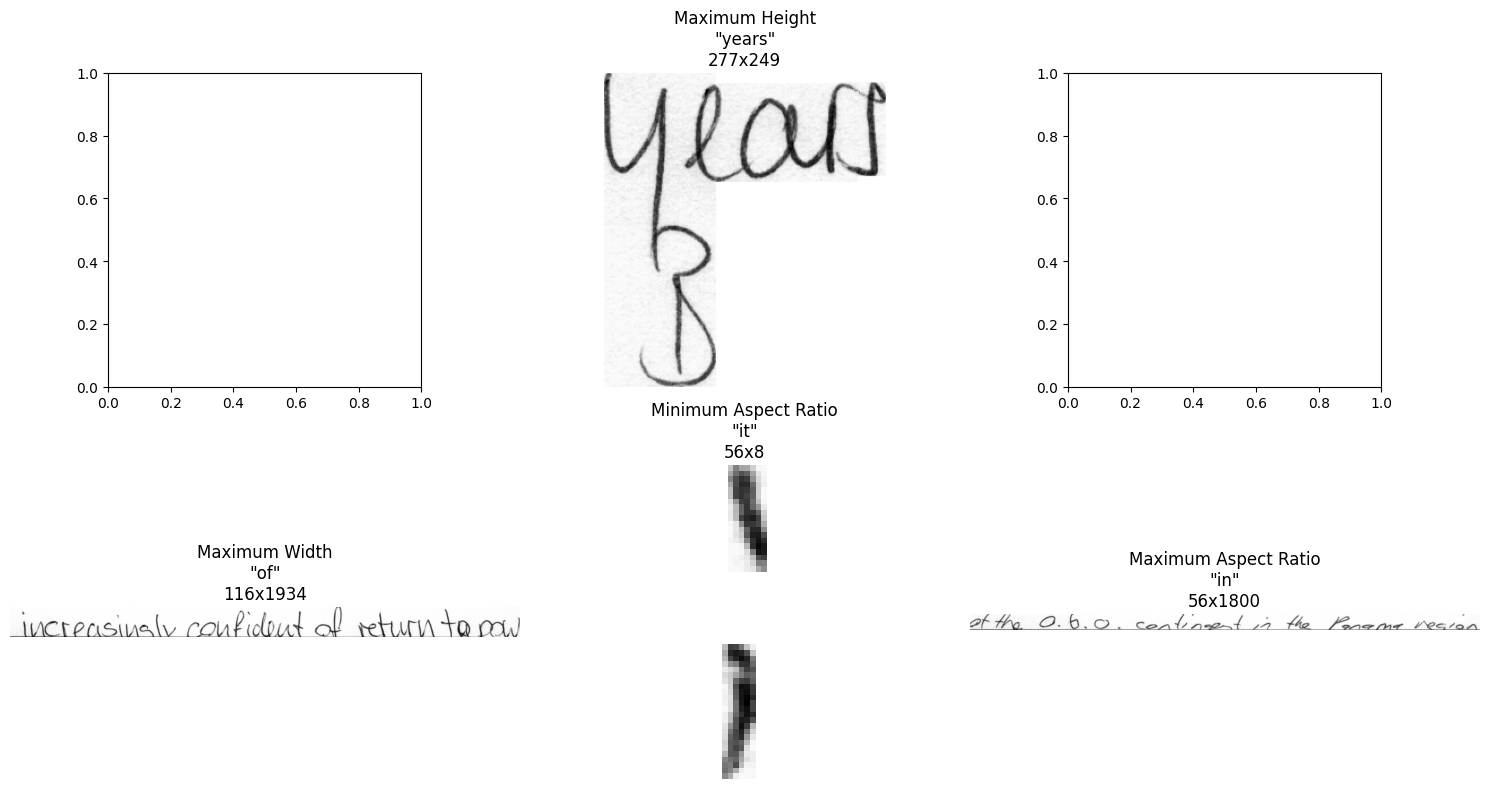

In [5]:

# Print some statistics
print("\nImage Dimension Statistics:")
print(f"Height - Mean: {np.mean(heights):.1f}, Min: {min(heights)}, Max: {max(heights)}")
print(f"Width  - Mean: {np.mean(widths):.1f}, Min: {min(widths)}, Max: {max(widths)}")
print(f"Aspect Ratio - Mean: {np.mean(aspect_ratios):.2f}, Min: {min(aspect_ratios):.2f}, Max: {max(aspect_ratios):.2f}")

# Show examples of extreme cases
plt.figure(figsize=(15, 8))

# Find indices of extreme cases
min_height_idx = heights.index(min(heights))
max_height_idx = heights.index(max(heights))
min_width_idx = widths.index(min(widths))
max_width_idx = widths.index(max(widths))
min_aspect_idx = aspect_ratios.index(min(aspect_ratios))
max_aspect_idx = aspect_ratios.index(max(aspect_ratios))

extreme_cases = [
    (min_height_idx, "Minimum Height"),
    (max_height_idx, "Maximum Height"),
    (min_width_idx, "Minimum Width"),
    (max_width_idx, "Maximum Width"),
    (min_aspect_idx, "Minimum Aspect Ratio"),
    (max_aspect_idx, "Maximum Aspect Ratio")
]

for i, (idx, title) in enumerate(extreme_cases):
    img, text = dataset[idx]
    decoded_text = dataset.decode_text(text)
    
    plt.subplot(2, 3, i+1)
    try:
        plt.imshow(img.squeeze().numpy(), cmap='gray')
    except Exception as e:
        print(f"Error at index {idx}: {e}")
        continue
    plt.title(f'{title}\n"{decoded_text}"\n{img.shape[1]}x{img.shape[2]}')
    plt.axis('off')

plt.tight_layout()
plt.show()


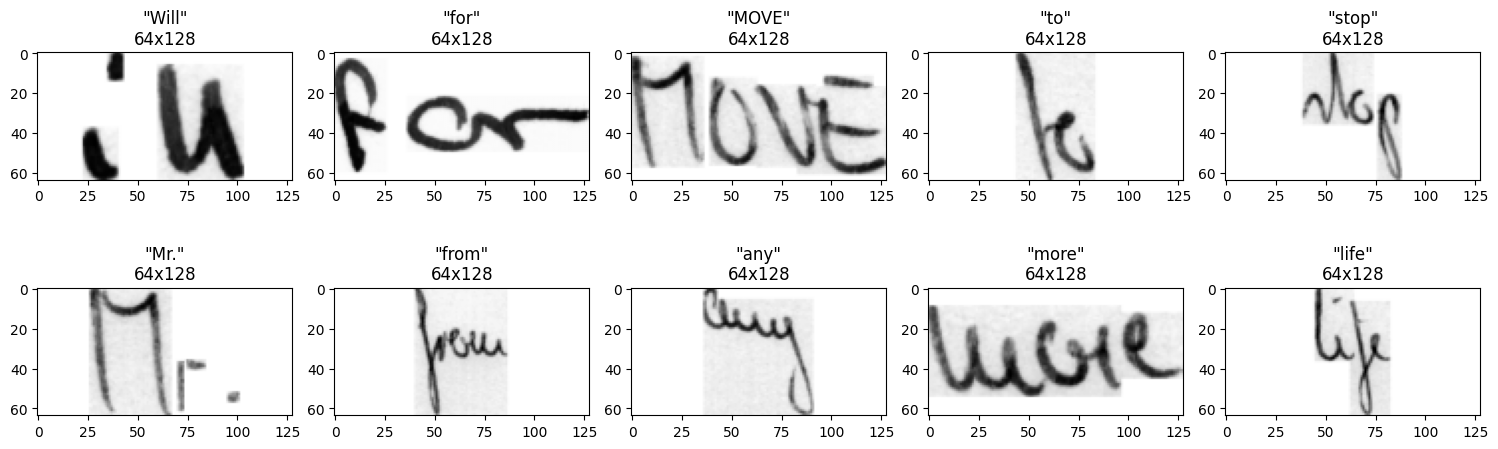

In [15]:

# Show some examples with standardized aspect ratio
plt.figure(figsize=(15, 5))
for i in range(10):
    img, text = dataset[i+30]
    decoded_text = dataset.decode_text(text)
    
    plt.subplot(2, 5, i+1)
    plt.imshow(img.squeeze().numpy(), cmap='gray')
    plt.title(f'"{decoded_text}"\n{img.shape[1]}x{img.shape[2]}')
    # plt.axis('off')

plt.tight_layout()
plt.show()
